# Intensity Measure Selection Using the Relative Sufficiency Measure

## Introduction

This notebook demonstrates the **Intensity Measure (IM) selection framework as implemented in the `imselection` class of OQ-VMTK. The framework evaluates competing IMs using four metrics:
- **Efficiency**: The dispersion of structural demand $D$ conditioned on the IM — $\beta_{D|IM}$ — quantifies how tightly the IM predicts structural response. **Lower values indicate a more efficient IM.**
- **Proficiency**: The dispersion of the IM conditioned on reaching a limit state $\beta_{IM|DCR=1}$, estimated as:
$$\beta_{IM|DCR=1} = \frac{1}{2}\ln\left(\frac{IM_{84\%}}{IM_{16\%}}\right)$$
where $IM_{16\%}$ and $IM_{84\%}$ are the IM values at which the fragility curve reaches 16% and 84% exceedance probability. **Lower values indicate a more proficient IM.**
- **Practicality**: The slope $b$ of the log-linear regression $\log(EDP) = b_0 + b \cdot \log(IM)$, which measures the strength of the IM–EDP power-law relationship. **Higher values indicate a more practical IM** (a unit increase in ln(IM) produces a larger shift in structural demand).
- **Relative Sufficiency Measure**: An information-theoretic metric — in **bits** — that quantifies how much more structural-demand information $IM_2$ carries relative to $IM_1$:
$$RSM(IM_2 \text{ vs } IM_1) = \frac{1}{N}\sum_{k=1}^{N}\log_2\frac{f(D_k|IM_2=im_{2,k})}{f(D_k|IM_1=im_{1,k})} \quad \text{(Eq. 1)}$$ **A positive RSM means $IM_2$ is more sufficient than $IM_1$.**

## References
[1] Ebrahimian H, Jalayer F. Selection of seismic intensity measures for prescribed limit states using alternative nonlinear dynamic analysis methods. Earthquake Engng Struct Dyn. 2021;50:1235–1250. https://doi.org/10.1002/eqe.3393

[2] Padgett, J. E., Nielson, B. G., & DesRoches, R. (2008). Selection of optimal intensity measures in probabilistic seismic demand models of highway bridge portfolios. Earthquake Engineering & Structural Dynamics, 37(5), 711–725. https://doi.org/10.1002/eqe.782

[3] Pledger, L, Sistla, S, Pujol, S, Chandramohan, R. A Comparison of Ground Motion Intensity Measures for Estimating Collapse, Earthquake Spectra 2026, 42, e70063. https://doi.org/10.1002/esp4.70063

[4] Kazantzi, A. K., & Vamvatsikos, D. (2015). Intensity measure selection for vulnerability studies of building classes. Earthquake Engineering & Structural Dynamics, 44(15), 2677–2694. https://doi.org/10.1002/eqe.2603


## Initialise Libraries

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openquake.vmtk.postprocessor import postprocessor
from openquake.vmtk.imselection import imselection
from openquake.vmtk.utilities import import_from_pkl

# Part I — MCA-Based IM Selection

## Define Directories and Analysis Parameters

In [2]:
# ---------------------------------------------------------------
# Paths — point to the FragilityAnalysis demo inputs
# ---------------------------------------------------------------
mca_input_dir = os.path.join('..', 'FragilityAnalysis', 'in')
out_dir = './out'
os.makedirs(out_dir, exist_ok=True)

# ---------------------------------------------------------------
# Analysis parameters (same as FragilityAnalysis demo)
# ---------------------------------------------------------------
# Fundamental period of the 2-storey model (from modal analysis)
T1 = 0.154  # seconds

# Damage state thresholds (maximum peak storey drift, dimensionless)
damage_thresholds = [0.00150, 0.00545, 0.00952, 0.01350]
lower_limit = 0.1 * damage_thresholds[0]   # ignore negligible demands
censored_limit = 1.5 * damage_thresholds[-1]  # collapse proxy

# IMs to compare
# SA(0.3s) is close to 2*T1 (T1=0.154s); AvgSA is the geometric mean
# over a broad period range — expected to be most sufficient.
im_keys_mca = ['PGA', 'SA(0.3s)', 'AvgSA']

print('MCA input directory :', os.path.abspath(mca_input_dir))
print('IMs to compare      :', im_keys_mca)
print('lower_limit         :', lower_limit)
print('censored_limit      :', censored_limit)

MCA input directory : /Users/mnafeh/Documents/GitHub/oq-vmtk/demos/FragilityAnalysis/in
IMs to compare      : ['PGA', 'SA(0.3s)', 'AvgSA']
lower_limit         : 0.00015000000000000001
censored_limit      : 0.02025


## Load Pre-Computed IM and EDP Data

In [3]:
# Pre-computed intensity measures for 200 ground motion records
ims = import_from_pkl(os.path.join(mca_input_dir, 'imls_esrm20.pkl'))
print('Available IM types:', list(ims.keys()))
print('Number of records  :', len(ims['PGA']))

# NLTHA results (max peak storey drift per record)
ansys_mca = import_from_pkl(os.path.join(mca_input_dir, 'ansys_out.pkl'))
edps_mca = np.array(ansys_mca['max_peak_drift_list'])
print('EDP range (drift)  : [{:.4f}, {:.4f}]'.format(edps_mca.min(), edps_mca.max()))

Available IM types: ['PGA', 'PGV', 'PGD', 'SA(0.3s)', 'SA(0.6s)', 'SA(1.0s)', 'AvgSA', 'AvgSA(0.3s)', 'AvgSA(0.6s)', 'AvgSA(1.0s)', 'AI', 'D595']
Number of records  : 200
EDP range (drift)  : [0.0001, 0.2259]


## Run Modified Cloud Analysis for Each IM

In [4]:
pp = postprocessor()
cloud_dicts = {}

for im_key in im_keys_mca:
    print(f'Running MCA for {im_key} ...')
    cloud_dicts[im_key] = pp.process_mca_results(
        ims[im_key],
        edps_mca,
        damage_thresholds,
        lower_limit,
        censored_limit,
        sigma_build2build=0.0,
        sigma_ds=0.0,
        fragility_method='lognormal')
    reg = cloud_dicts[im_key]['regression']
    print(f'  b1={reg["b1"]:.3f}  b0={reg["b0"]:.3f}  sigma={reg["sigma"]:.3f}')

print('\nMCA complete for all IMs.')

Running MCA for PGA ...
  b1=1.126  b0=-4.782  sigma=0.704
Running MCA for SA(0.3s) ...
  b1=1.083  b0=-5.300  sigma=0.505
Running MCA for AvgSA ...
  b1=1.275  b0=-4.194  sigma=0.440

MCA complete for all IMs.


## Visualise Cloud Regressions

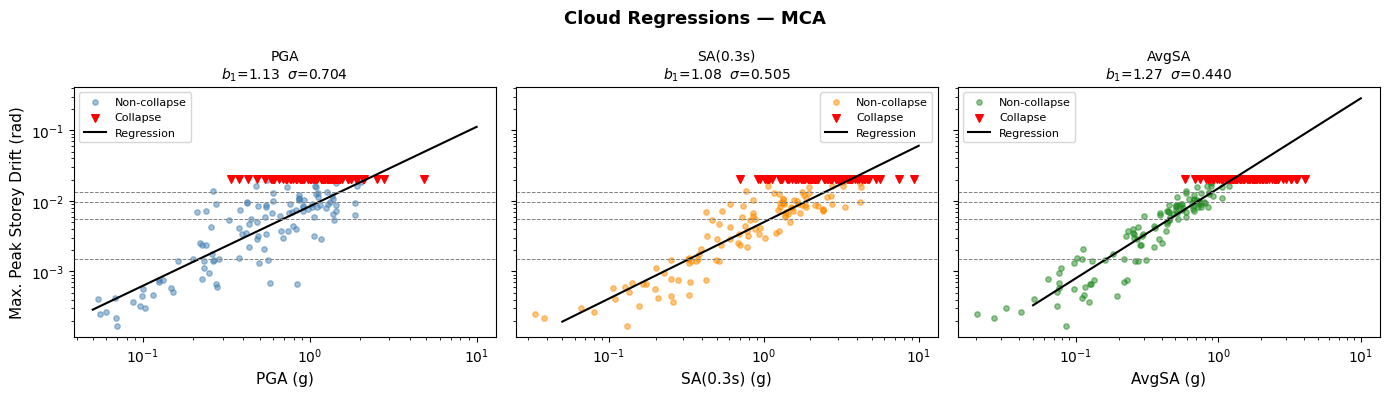

In [5]:
colors = ['steelblue', 'darkorange', 'forestgreen']
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, im_key, color in zip(axes, im_keys_mca, colors):
    cd = cloud_dicts[im_key]
    im_nc = cd['raw_data']['im_nc']
    edp_nc = cd['raw_data']['edp_nc']
    im_c = cd['raw_data']['im_c']
    reg = cd['regression']

    # Scatter
    ax.scatter(im_nc, edp_nc, s=15, alpha=0.5, color=color,
               label='Non-collapse')
    if len(im_c) > 0:
        ax.scatter(im_c, np.full_like(im_c, censored_limit),
                   s=30, marker='v', color='red', label='Collapse')

    # Regression line
    im_fit = np.exp(reg['fitted_x'])
    edp_fit = np.exp(reg['fitted_y'])
    ax.plot(im_fit, edp_fit, 'k-', linewidth=1.5, label='Regression')

    # Damage thresholds
    for ds_val in damage_thresholds:
        ax.axhline(ds_val, color='grey', linestyle='--', linewidth=0.7)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(im_key + ' (g)', fontsize=11)
    ax.set_title(
        f'{im_key}\n'
        r'$b_1$='+f'{reg["b1"]:.2f}  '
        r'$\sigma$='+f'{reg["sigma"]:.3f}',
        fontsize=10)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Max. Peak Storey Drift (rad)', fontsize=11)
fig.suptitle('Cloud Regressions — MCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'mca_cloud_regressions.png'), dpi=150)
plt.show()

## Efficiency and Proficiency — MCA

In [6]:
ims_selector = imselection()

rows = []
for im_key in im_keys_mca:
    eff = ims_selector.compute_efficiency_mca(cloud_dicts[im_key])
    prof = ims_selector.compute_proficiency_mca(cloud_dicts[im_key], ds_index=0)
    rows.append({
        'IM': im_key,
        'Efficiency β_D|IM': round(eff['beta_D_given_IM'], 4),
        'Proficiency β_IM|DCR=1': round(prof['beta_IM_given_DCRLS1'], 4),
        'β_formula (σ/b)': round(prof['beta_formula'], 4),
        'IM₁₆% (g)': round(prof['im16'], 4),
        'IM₈₄% (g)': round(prof['im84'], 4),
    })

df_mca_metrics = pd.DataFrame(rows).set_index('IM')
print('MCA — Efficiency and Proficiency (DS1):')
print(df_mca_metrics.to_string())

MCA — Efficiency and Proficiency (DS1):
          Efficiency β_D|IM  Proficiency β_IM|DCR=1  β_formula (σ/b)  IM₁₆% (g)  IM₈₄% (g)
IM                                                                                        
PGA                  0.7037                  0.6061           0.6252     0.1149     0.3861
SA(0.3s)             0.5048                  0.4623           0.4661     0.2051     0.5171
AvgSA                0.4400                  0.3465           0.3452     0.1150     0.2300


## Practicality — MCA

**Practicality** measures the strength of the IM–EDP power-law relationship via the regression slope $b$. A higher $b$ means a unit increase in $\ln(IM)$ produces a larger shift in $\ln(EDP)$ — i.e., the IM is a more practical predictor of structural demand.

In [7]:
rows_prac_mca = []
for im_key in im_keys_mca:
    prac = ims_selector.compute_practicality_mca(cloud_dicts[im_key])
    rows_prac_mca.append({
        'IM': im_key,
        'Practicality b (slope)': round(prac['b_slope'], 4),
    })

df_prac_mca = pd.DataFrame(rows_prac_mca).set_index('IM')
print('MCA — Practicality (DS1):')
print(df_prac_mca.to_string())

MCA — Practicality (DS1):
          Practicality b (slope)
IM                              
PGA                       1.1256
SA(0.3s)                  1.0831
AvgSA                     1.2745


## Pairwise RSM — MCA

A **positive RSM(IM₂ vs IM₁)** means IM₂ carries more structural-demand information than IM₁.

In [8]:
print('Pairwise RSM (bits) — MCA')
print('-' * 60)
print(f'  {"IM₁":<12} {"IM₂":<12} {"RSM (bits)":>12}  Interpretation')
print('-' * 60)
for i, im1 in enumerate(im_keys_mca):
    for j, im2 in enumerate(im_keys_mca):
        if i == j:
            continue
        rsm_result = ims_selector.compute_rsm_mca(
            cloud_dicts[im1], cloud_dicts[im2])
        rsm_val = rsm_result['rsm']
        note = 'IM₂ more sufficient' if rsm_val > 0 else 'IM₁ more sufficient'
        print(f'  {im1:<12} {im2:<12} {rsm_val:>12.4f}  {note}')
print('-' * 60)

Pairwise RSM (bits) — MCA
------------------------------------------------------------
  IM₁          IM₂            RSM (bits)  Interpretation
------------------------------------------------------------
  PGA          SA(0.3s)           0.5237  IM₂ more sufficient
  PGA          AvgSA              1.1244  IM₂ more sufficient
  SA(0.3s)     PGA               -0.5237  IM₁ more sufficient
  SA(0.3s)     AvgSA              0.6007  IM₂ more sufficient
  AvgSA        PGA               -1.1244  IM₁ more sufficient
  AvgSA        SA(0.3s)          -0.6007  IM₁ more sufficient
------------------------------------------------------------


## IM Ranking and RSM Heatmap — MCA

IM Ranking — MCA:
 im_name  efficiency  rank_efficiency  proficiency  rank_proficiency  practicality  rank_practicality  rsm_vs_reference  rank_rsm
     PGA    0.703721                3     0.606150                 3      1.125579                  2          0.000000         3
SA(0.3s)    0.504796                2     0.462312                 2      1.083103                  3          0.523666         2
   AvgSA    0.439965                1     0.346464                 1      1.274538                  1          1.124356         1


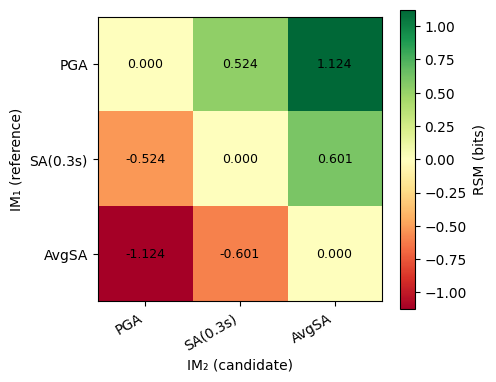

In [9]:
comparison_mca = ims_selector.compare_ims(
    cloud_dicts,
    analysis_type='MCA',
    reference_im_key='PGA',
    damage_threshold_index=0)

print('IM Ranking — MCA:')
print(comparison_mca['ranking'][[
    'im_name',
    'efficiency', 'rank_efficiency',
    'proficiency', 'rank_proficiency',
    'practicality', 'rank_practicality',
    'rsm_vs_reference', 'rank_rsm']].to_string(index=False))

# RSM heatmap
mat = comparison_mca['rsm_matrix']
im_list = im_keys_mca
rsm_array = np.array([[mat[r][c] for c in im_list] for r in im_list])

fig, ax = plt.subplots(figsize=(5, 4))
vmax = np.nanmax(np.abs(rsm_array))
im_plot = ax.imshow(rsm_array, cmap='RdYlGn', vmin=-vmax, vmax=vmax)
plt.colorbar(im_plot, ax=ax, label='RSM (bits)')
ax.set_xticks(range(len(im_list)))
ax.set_yticks(range(len(im_list)))
ax.set_xticklabels(im_list, rotation=30, ha='right')
ax.set_yticklabels(im_list)
ax.set_xlabel('IM₂ (candidate)')
ax.set_ylabel('IM₁ (reference)')
for r in range(len(im_list)):
    for c in range(len(im_list)):
        val = rsm_array[r, c]
        ax.text(c, r, f'{val:.3f}' if np.isfinite(val) else '—',
                ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'mca_rsm_heatmap.png'), dpi=150)
plt.show()

# Part II — IDA-Based IM Selection

## Define Directories and Analysis Parameters

In [10]:
# ---------------------------------------------------------------
# Paths — pre-computed IDA inputs bundled with this demo
# ---------------------------------------------------------------
ida_in_dir = './in'

# ---------------------------------------------------------------
# Analysis parameters (same as IncrementalDynamicAnalysis demo)
# ---------------------------------------------------------------
damage_thresholds_ida = [0.00400, 0.00545, 0.00952, 0.01350]
im_keys_ida = ['PGA', 'SA(0.3s)', 'AvgSA']

print('IDA data directory :', os.path.abspath(ida_in_dir))
print('IMs to compare     :', im_keys_ida)

IDA data directory : /Users/mnafeh/Documents/GitHub/oq-vmtk/demos/IntensityMeasureSelection/in
IMs to compare     : ['PGA', 'SA(0.3s)', 'AvgSA']


## Load Pre-computed IDA Inputs and NLTHA Results

In [11]:
# Scaled IMs — shape (n_records × max_runs) for each IM type
imls_sf = import_from_pkl(os.path.join(ida_in_dir, 'imls_femap695_sf.pkl'))
print('Available IM types (scaled):', list(imls_sf.keys()))
print('im_matrix shape            :', np.array(imls_sf['PGA']).shape)

# NLTHA results from IDA
ansys_ida = import_from_pkl(os.path.join(ida_in_dir, 'ida_ansys_out.pkl'))
print('\nIDA ansys_dict keys:', list(ansys_ida.keys()))
print('Number of records  :', len(ansys_ida['max_peak_drift_list']))

Available IM types (scaled): ['PGA', 'SA(0.3s)', 'AvgSA']
im_matrix shape            : (44, 30)

IDA ansys_dict keys: ['T', 'conv_index_list', 'peak_drift_list', 'peak_accel_list', 'max_peak_drift_list', 'max_peak_drift_dir_list', 'max_peak_drift_loc_list', 'max_peak_accel_list', 'max_peak_accel_dir_list', 'max_peak_accel_loc_list', 'peak_disp_list', 'sf_matrix']
Number of records  : 44


## Run IDA Post-processing for Each IM

For each IM type, the same NLTHA results are post-processed with a different
`im_matrix` — this is possible because the IDA post-processor interprets the
structural response (drift) against the scaled IM values for that specific IM
type.

In [12]:
ida_dicts = {}

for im_key in im_keys_ida:
    print(f'Post-processing IDA for {im_key} ...')
    im_matrix = np.array(imls_sf[im_key])  # shape (44, 30)
    ida_dicts[im_key] = pp.process_ida_results(
        ansys_ida,
        im_matrix,
        damage_thresholds_ida,
        edp_key='max_peak_drift_list',
        sigma_build2build=0.3,
        intensities=np.round(np.geomspace(0.05, 10.0, 50), 3),
        edp_range=np.linspace(0.00, 0.05, 101),
        fragility_rotation=False,
        rotation_percentile=0.10)
    medians = ida_dicts[im_key]['fragility']['medians']
    sigmas = ida_dicts[im_key]['fragility']['sigma_record2record']
    print(f'  DS1 median={medians[0]:.3f} g  sigma_r2r={sigmas[0]:.3f}')

print('\nIDA post-processing complete for all IMs.')

Post-processing IDA for PGA ...
  DS1 median=0.240 g  sigma_r2r=0.241
Post-processing IDA for SA(0.3s) ...
  DS1 median=0.535 g  sigma_r2r=0.334
Post-processing IDA for AvgSA ...
  DS1 median=0.395 g  sigma_r2r=0.162

IDA post-processing complete for all IMs.


/Users/mnafeh/Documents/GitHub/oq-vmtk/openquake/vmtk/postprocessor.py:1858: RuntimeWarning: All-NaN slice encountered
  median_ida_im = np.nanmedian(im_at_edp_matrix, axis=0)
/Users/mnafeh/Desktop/oq-vmtk/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


## Visualise IDA Curves

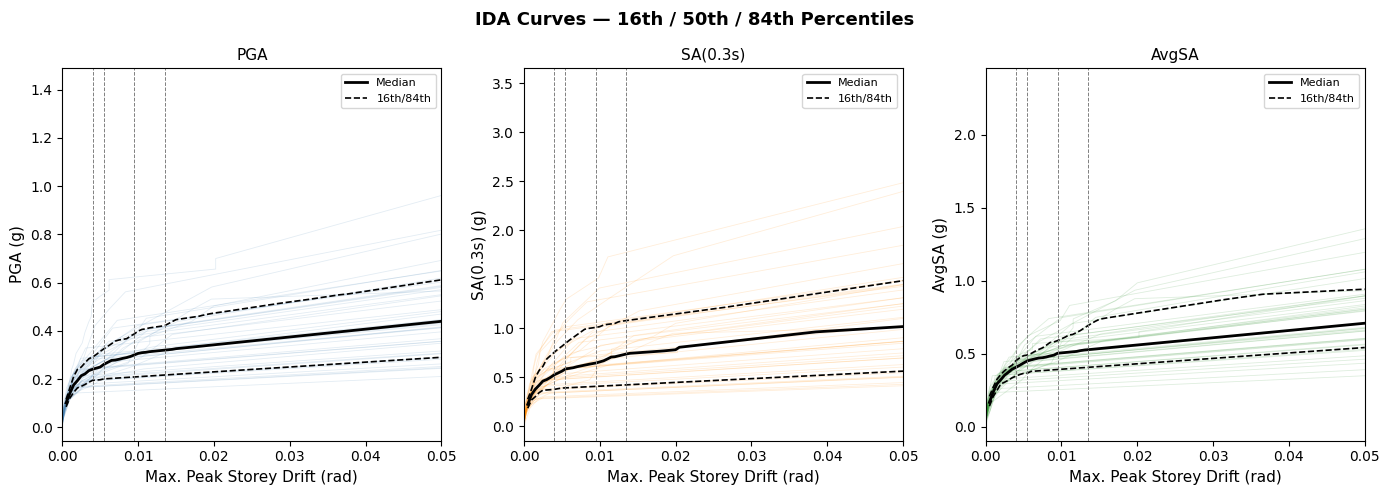

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True)

for ax, im_key, color in zip(axes, im_keys_ida, colors):
    ida = ida_dicts[im_key]
    raw_curves = ida['ida_inputs']['raw_curves']
    edp_axis = np.array(ida['stats']['fitted_edps'])
    median_im = np.array(ida['stats']['median_im'])
    p16_im = np.array(ida['stats']['p16_im'])
    p84_im = np.array(ida['stats']['p84_im'])

    # Individual IDA curves — EDP on x, IM on y
    for curve in raw_curves:
        ax.plot(curve['edp'], curve['im'], color=color,
                alpha=0.15, linewidth=0.6)

    # Percentile curves — EDP on x, IM on y
    ax.plot(edp_axis, median_im, 'k-',  linewidth=2.0, label='Median')
    ax.plot(edp_axis, p16_im,    'k--', linewidth=1.2, label='16th/84th')
    ax.plot(edp_axis, p84_im,    'k--', linewidth=1.2)

    # Damage thresholds as vertical lines (EDP on x-axis)
    for ds_val in damage_thresholds_ida:
        ax.axvline(ds_val, color='grey', linestyle='--', linewidth=0.7)

    ax.set_xlabel('Max. Peak Storey Drift (rad)', fontsize=11)
    ax.set_ylabel(im_key + ' (g)', fontsize=11)
    ax.set_title(im_key, fontsize=11)
    ax.set_xlim([0, 0.05])
    ax.legend(fontsize=8)

fig.suptitle('IDA Curves — 16th / 50th / 84th Percentiles', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'ida_curves.png'), dpi=150)
plt.show()

## Efficiency and Proficiency — IDA

In [14]:
rows_ida = []
for im_key in im_keys_ida:
    eff = ims_selector.compute_efficiency_ida(ida_dicts[im_key], ds_index=0)
    prof = ims_selector.compute_proficiency_ida(ida_dicts[im_key], ds_index=0)
    rows_ida.append({
        'IM': im_key,
        'Efficiency β_D|IM': round(eff['beta_D_given_IM'], 4),
        'Proficiency β_IM|DCR=1': round(prof['beta_IM_given_DCRLS1'], 4),
        'IM₁₆% (g)': round(prof['im16'], 4),
        'IM₈₄% (g)': round(prof['im84'], 4),
    })

df_ida_metrics = pd.DataFrame(rows_ida).set_index('IM')
print('IDA — Efficiency and Proficiency (DS1):')
print(df_ida_metrics.to_string())

IDA — Efficiency and Proficiency (DS1):
          Efficiency β_D|IM  Proficiency β_IM|DCR=1  IM₁₆% (g)  IM₈₄% (g)
IM                                                                       
PGA                  0.2408                  0.2009     0.1953     0.2919
SA(0.3s)             0.3340                  0.3485     0.3757     0.7543
AvgSA                0.1615                  0.1329     0.3468     0.4524


## Practicality — IDA

**Practicality** for IDA is estimated as the OLS slope of $\log(EDP)$ on $\log(IM)$ along the median IDA curve, mirroring the MCA convention. A higher slope indicates a stronger IM–EDP relationship.

In [15]:
rows_prac_ida = []
for im_key in im_keys_ida:
    prac = ims_selector.compute_practicality_ida(ida_dicts[im_key])
    rows_prac_ida.append({
        'IM': im_key,
        'Practicality b (slope)': round(prac['b_slope'], 4),
    })

df_prac_ida = pd.DataFrame(rows_prac_ida).set_index('IM')
print('IDA — Practicality:')
print(df_prac_ida.to_string())

IDA — Practicality:
          Practicality b (slope)
IM                              
PGA                       3.8123
SA(0.3s)                  3.4694
AvgSA                     3.9627


## Pairwise RSM — IDA

In [16]:
print('Pairwise RSM (bits) — IDA')
print('-' * 60)
print(f'  {"IM₁":<12} {"IM₂":<12} {"RSM (bits)":>12}  n_valid')
print('-' * 60)
for i, im1 in enumerate(im_keys_ida):
    for j, im2 in enumerate(im_keys_ida):
        if i == j:
            continue
        rsm_result = ims_selector.compute_rsm_ida(
            ida_dicts[im1], ida_dicts[im2])
        rsm_val = rsm_result['rsm']
        n_v = rsm_result['n_valid']
        print(f'  {im1:<12} {im2:<12} {rsm_val:>12.4f}  {n_v}')
print('-' * 60)

Pairwise RSM (bits) — IDA
------------------------------------------------------------
  IM₁          IM₂            RSM (bits)  n_valid
------------------------------------------------------------
  PGA          SA(0.3s)          -0.9558  44
  PGA          AvgSA             -1.0600  44
  SA(0.3s)     PGA                0.9558  44
  SA(0.3s)     AvgSA             -0.1043  44
  AvgSA        PGA                1.0600  44
  AvgSA        SA(0.3s)           0.1043  44
------------------------------------------------------------


## IM Ranking and RSM Heatmap — IDA

IM Ranking — IDA:
 im_name  efficiency  rank_efficiency  proficiency  rank_proficiency  practicality  rank_practicality  rsm_vs_reference  rank_rsm
     PGA    0.240774                2     0.200915                 2      3.812325                  2          0.000000         1
SA(0.3s)    0.333995                3     0.348497                 3      3.469405                  3         -0.955792         2
   AvgSA    0.161544                1     0.132925                 1      3.962711                  1         -1.060043         3


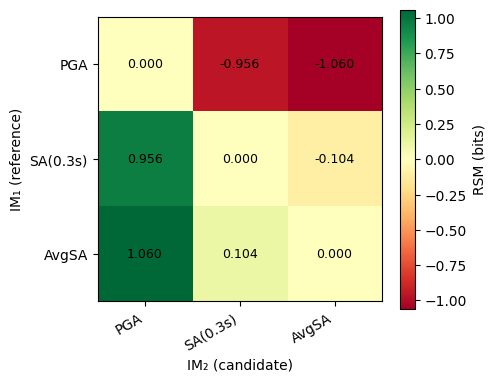

In [17]:
comparison_ida = ims_selector.compare_ims(
    ida_dicts,
    analysis_type='IDA',
    reference_im_key='PGA',
    damage_threshold_index=0)

print('IM Ranking — IDA:')
print(comparison_ida['ranking'][[
    'im_name',
    'efficiency', 'rank_efficiency',
    'proficiency', 'rank_proficiency',
    'practicality', 'rank_practicality',
    'rsm_vs_reference', 'rank_rsm']].to_string(index=False))

# RSM heatmap
mat_ida = comparison_ida['rsm_matrix']
rsm_array_ida = np.array(
    [[mat_ida[r][c] for c in im_keys_ida] for r in im_keys_ida])

fig, ax = plt.subplots(figsize=(5, 4))
vmax_ida = np.nanmax(np.abs(rsm_array_ida))
im_plot = ax.imshow(rsm_array_ida, cmap='RdYlGn',
                    vmin=-vmax_ida, vmax=vmax_ida)
plt.colorbar(im_plot, ax=ax, label='RSM (bits)')
ax.set_xticks(range(len(im_keys_ida)))
ax.set_yticks(range(len(im_keys_ida)))
ax.set_xticklabels(im_keys_ida, rotation=30, ha='right')
ax.set_yticklabels(im_keys_ida)
ax.set_xlabel('IM₂ (candidate)')
ax.set_ylabel('IM₁ (reference)')
for r in range(len(im_keys_ida)):
    for c in range(len(im_keys_ida)):
        val = rsm_array_ida[r, c]
        ax.text(c, r, f'{val:.3f}' if np.isfinite(val) else '—',
                ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'ida_rsm_heatmap.png'), dpi=150)
plt.show()

# Part III — MCA vs IDA Comparison

## Side-by-Side Metric Comparison

In [18]:
df_mca = comparison_mca['ranking'].set_index('im_name').rename(
    columns={
        'efficiency':    'MCA efficiency',
        'proficiency':   'MCA proficiency',
        'practicality':  'MCA practicality',
        'rsm_vs_reference': 'MCA RSM vs PGA',
        'rank_rsm':      'MCA rank',
    })[['MCA efficiency', 'MCA proficiency', 'MCA practicality',
        'MCA RSM vs PGA', 'MCA rank']]

df_ida = comparison_ida['ranking'].set_index('im_name').rename(
    columns={
        'efficiency':    'IDA efficiency',
        'proficiency':   'IDA proficiency',
        'practicality':  'IDA practicality',
        'rsm_vs_reference': 'IDA RSM vs PGA',
        'rank_rsm':      'IDA rank',
    })[['IDA efficiency', 'IDA proficiency', 'IDA practicality',
        'IDA RSM vs PGA', 'IDA rank']]

df_combined = df_mca.join(df_ida)
print('MCA vs IDA — Metric Comparison:')
print(df_combined.to_string())

MCA vs IDA — Metric Comparison:
          MCA efficiency  MCA proficiency  MCA practicality  MCA RSM vs PGA  MCA rank  IDA efficiency  IDA proficiency  IDA practicality  IDA RSM vs PGA  IDA rank
im_name                                                                                                                                                           
PGA             0.703721         0.606150          1.125579        0.000000         3        0.240774         0.200915          3.812325        0.000000         1
SA(0.3s)        0.504796         0.462312          1.083103        0.523666         2        0.333995         0.348497          3.469405       -0.955792         2
AvgSA           0.439965         0.346464          1.274538        1.124356         1        0.161544         0.132925          3.962711       -1.060043         3


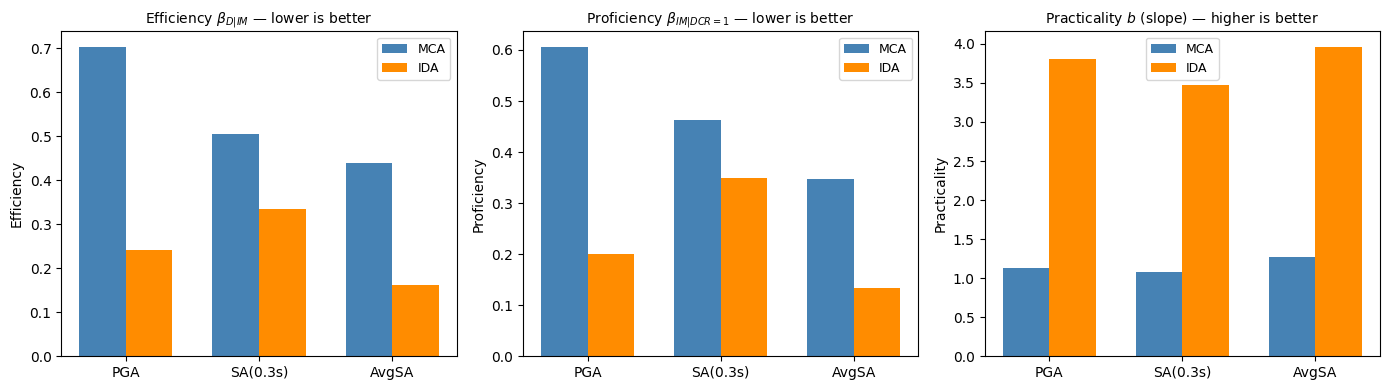

In [19]:
# Bar chart: efficiency, proficiency, and practicality side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x = np.arange(len(im_keys_mca))
width = 0.35

panels = [
    ('efficiency',   r'Efficiency $\beta_{D|IM}$ — lower is better',   True),
    ('proficiency',  r'Proficiency $\beta_{IM|DCR=1}$ — lower is better', True),
    ('practicality', r'Practicality $b$ (slope) — higher is better',   False),
]

for ax, (metric, title, lower_better) in zip(axes, panels):
    mca_vals = comparison_mca['ranking'].set_index('im_name')[metric].values
    ida_vals = comparison_ida['ranking'].set_index('im_name')[metric].values

    ax.bar(x - width / 2, mca_vals, width, label='MCA', color='steelblue')
    ax.bar(x + width / 2, ida_vals, width, label='IDA', color='darkorange')
    ax.set_xticks(x)
    ax.set_xticklabels(im_keys_mca)
    ax.set_ylabel(metric.capitalize())
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'mca_vs_ida_metrics.png'), dpi=150)
plt.show()

## Interpretation Guide

### Sign convention
- $RSM(IM_2 \text{ vs } IM_1) > 0$ → $IM_2$ carries **more** structural-demand information than $IM_1$ (more sufficient).
- $RSM = 0$ → both IMs are equally informative given the dataset.
- The RSM is **anti-symmetric**: $RSM(IM_2 \text{ vs } IM_1) = -RSM(IM_1 \text{ vs } IM_2)$.

### MCA vs IDA differences
- In **MCA**, $f(D|IM)$ is modelled as a lognormal with a power-law mean; the RSM captures both regression slope and scatter.
- In **IDA**, the density is derived from the empirical fan of IDA curves (16th/84th percentiles), making it more sensitive to the shape of the IDA distribution.
- Slight differences in ranking between MCA and IDA are expected and reflect different modelling assumptions.

### Record-ordering contract
Both `cloud_dicts` (or `ida_dicts`) passed to the RSM functions must be derived from **the same N records in the same order**, using the same `censored_limit` and `lower_limit`. Under this contract the EDP-based collapse split and lower-EDP filter are identical for all IMs, ensuring correct positional alignment.

### Caveats
- The RSM is a **dataset-specific** measure — results may vary with the choice of ground motion set.
- For very small N (< 20 records), the mean RSM may be noisy.
- The logistic collapse model used in MCA may be poorly constrained if few records collapse.
- IDA RSM validity depends on the IDA fan being well-sampled (sufficient records and scale-factor levels).